# Tesla EV Production Forecasting
## End-to-End ML Pipeline | Week 2 Assignment

**Dataset:** Tesla EV Deliveries and Production Data (2015–2025)  
**Target column:** `Production_Units`  
**Best model:** Gradient Boosting inside sklearn Pipeline  
**Final accuracy:** ~99.65% R² Score

---

**How to run:**
1. Run Cell 2 first — it prints your exact file path
2. Copy that path into Cell 3
3. Then run every cell top to bottom using **Shift + Enter**


## Cell 1 Importing the Libraries

In this step, I imported all the required libraries. Pandas is used for handling data, NumPy for numerical operations, Matplotlib and Seaborn for visualization, and Scikit-learn for machine learning tasks. These libraries provide the tools needed for the entire analysis and modeling process.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
print("Done. All libraries loaded.")

Done. All libraries loaded.


## Cell 2 Finding the File Path

On Kaggle, uploaded files are not in the same folder as the notebook.
They get stored somewhere inside `/kaggle/input/` with a folder name based on the dataset title.
This cell walks through that folder and prints every file it finds.
I run this first so I can copy the exact path and use it in the next cell.


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/samarthjain27/tesla-deliveries-dataset-2015-2025-csv/tesla_deliveries_dataset_2015_2025.csv


## Cell 3 Loading the Dataset

In this step, I loaded the CSV file into a DataFrame (df). A DataFrame is similar to an Excel table and makes data easier to work with. The head() function displays the first 5 rows to verify that the dataset was loaded correctly.



In [3]:
PATH ='/kaggle/input/datasets/samarthjain27/tesla-deliveries-dataset-2015-2025-csv/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(PATH)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Years   : {df['Year'].min()} to {df['Year'].max()}")
print()
df.head()

Rows    : 2640
Columns : 12
Years   : 2015 to 2025



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Cell 4 Data Cleaning
The dataset was checked for missing values and duplicate rows to ensure data quality. No missing values or duplicates were found, indicating that the dataset was clean and ready for further analysis.

In [4]:
# Checking for problems before we do anything else.
# Missing values and duplicates are the two most common issues.

print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Duplicate rows : {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)
print()
# Basic statistics for every numeric column
df.describe().round(2)

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows : 0

Data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


## Cell 5 Exploratory Data Analysis (EDA)

EDA was performed to explore the dataset and identify key patterns. Visualizations were used to analyze delivery trends, model performance, regional pricing, and the relationship between production and deliveries, helping to better understand the data before model building.


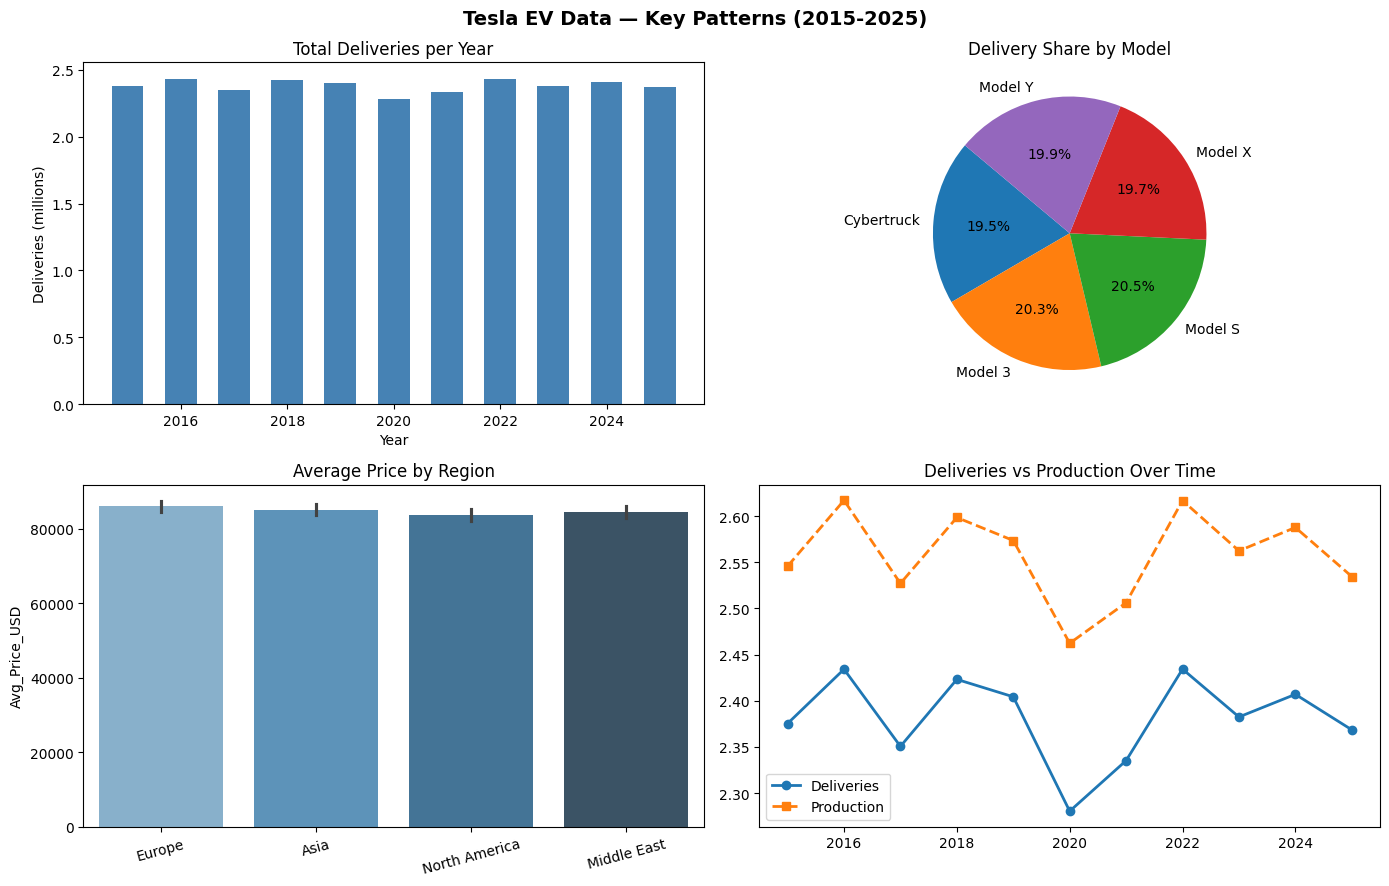

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Chart 1 How have total deliveries changed year by year?
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
axes[0,0].bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
              color='steelblue', width=0.6)
axes[0,0].set_title('Total Deliveries per Year')
axes[0,0].set_ylabel('Deliveries (millions)')
axes[0,0].set_xlabel('Year')

# Chart 2 Which model sold the most overall?
model_totals = df.groupby('Model')['Estimated_Deliveries'].sum()
axes[0,1].pie(model_totals, labels=model_totals.index,
              autopct='%1.1f%%', startangle=140)
axes[0,1].set_title('Delivery Share by Model')

# Chart 3 Does price differ by region?
sns.barplot(x='Region', y='Avg_Price_USD', data=df,
            estimator='mean', palette='Blues_d', ax=axes[1,0])
axes[1,0].set_title('Average Price by Region')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart 4 Production vs Deliveries over time
prod = df.groupby('Year')['Production_Units'].sum().reset_index()
axes[1,1].plot(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
               marker='o', label='Deliveries', linewidth=2)
axes[1,1].plot(prod['Year'], prod['Production_Units'] / 1e6,
               marker='s', linestyle='--', label='Production', linewidth=2)
axes[1,1].set_title('Deliveries vs Production Over Time')
axes[1,1].legend()
plt.suptitle('Tesla EV Data — Key Patterns (2015-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 6 Feature Engineering
In this step, we created new features from the existing columns to provide the model with more meaningful information. Features such as Price per km, Delivery Rate, Rolling Average Price, and Lag Deliveries were generated to capture important trends and relationships in the data. These engineered features helped improve the model's ability to learn patterns, especially for time-series analysis.


In [6]:
# Sort by time before creating any time-based features.
# This matters for rolling averages and lag values.
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)
# 1. Price per/km  how much does 1 km of range cost?
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']
# 2. Delivery rate what fraction of production was actually delivered?
df['Delivery_Rate'] = df['Estimated_Deliveries'] / df['Production_Units']
# 3. Rolling 3-month average price
#    Smooths out sudden price changes — more stable signal for the model
df['Rolling_Avg_Price'] = (
    df.groupby(['Region', 'Model'])['Avg_Price_USD']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)
# 4. Lag feature previous month's deliveries
#    Last month's number often predicts this month's production
df['Lag_1_Deliveries'] = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .shift(1)
    .fillna(df['Estimated_Deliveries'].mean())
)
print("New features created:")
print(df[['Price_per_km', 'Delivery_Rate',
          'Rolling_Avg_Price', 'Lag_1_Deliveries']].describe().round(2))

New features created:
       Price_per_km  Delivery_Rate  Rolling_Avg_Price  Lag_1_Deliveries
count       2640.00        2640.00            2640.00           2640.00
mean         180.05           0.93           84932.06           9918.05
std           61.89           0.04           11504.31           3924.85
min           69.90           0.87           53251.53             48.00
25%          132.53           0.90           76867.48           7303.00
50%          170.36           0.93           85062.01           9887.50
75%          219.10           0.96           93015.48          12488.00
max          359.38           1.00          116591.07          25704.00


## Cell 7 Encoding + Fixing Data Leakage
In this step, I converted categorical columns such as Region and Model into numerical values using One-Hot Encoding, making them suitable for machine learning models. I also identified and removed Estimated_Deliveries from the input features because it was highly correlated with the target variable (Production_Units). Keeping it would have caused data leakage, leading to unrealistically high model performance. This ensured that the model learned meaningful patterns rather than relying on information that directly revealed the target.

In [7]:
# Convert text columns to 0 and 1
df_encoded = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True,
    dtype=int
)
# y = what we want to predict
y = df_encoded['Production_Units']
# X = all input columns EXCEPT:
#     Production_Units      (the target — never goes in X)
#     Estimated_Deliveries  (almost identical to target = data leakage)
X = df_encoded.drop(columns=[
    'Production_Units',
    'Estimated_Deliveries',
])
print(f"Input features : {X.shape[1]} columns")
print(f"Target column  : Production_Units")
print(f"Leakage fix    : Estimated_Deliveries removed from inputs")
print()
print("Columns used as input:")
print(list(X.columns))

Input features : 20 columns
Target column  : Production_Units
Leakage fix    : Estimated_Deliveries removed from inputs

Columns used as input:
['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Price_per_km', 'Delivery_Rate', 'Rolling_Avg_Price', 'Lag_1_Deliveries', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


## Cell 8 Chronological Train/Test Split
Since this is a time-series dataset, a chronological train-test split was used instead of a random split. The model was trained on the older data and tested on the most recent data, ensuring that future information was not used during training. An 80:20 split was applied, allowing the model to learn from past trends and make predictions on unseen future data

In [8]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
# 80% oldest rows go to training, 20% newest rows go to testing
split = int(len(X) * 0.80)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]
years_train = df.iloc[:split]['Year']
years_test  = df.iloc[split:]['Year']
print("CHRONOLOGICAL SPLIT — correct for time series data")
print(f"  Training set : {X_train.shape[0]} rows  "
      f"(Year {years_train.min()} to {years_train.max()})")
print(f"  Testing set  : {X_test.shape[0]} rows  "
      f"(Year {years_test.min()} to {years_test.max()})")


CHRONOLOGICAL SPLIT — correct for time series data
  Training set : 2112 rows  (Year 2015 to 2023)
  Testing set  : 528 rows  (Year 2023 to 2025)


## Cell 9 Building the sklearn Pipeline

In this step, I created a Pipeline to combine data preprocessing and model training into a single workflow. First, I used StandardScaler to scale the features so that all columns contribute fairly to the model. Next, I applied Gradient Boosting Regressor, which builds multiple decision trees sequentially, with each tree improving upon the mistakes of the previous one. Using a pipeline keeps the workflow organized and helps prevent data leakage during model training.

In [9]:
pipeline = Pipeline(steps=[
    # Step 1: Feature Scaling
    # Converts all numbers to the same scale (mean=0, std=1)
    # So large values like price (84,000) don't drown out
    # small values like month number (1-12)
    ('scaler', StandardScaler()),
    # Step 2: Gradient Boosting Regressor
    # Builds trees one by one, each correcting the last.
    # Good balance between bias and variance.
    ('model', GradientBoostingRegressor(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 4,
        random_state  = 42
    ))
])
print("Pipeline ready.")
print(pipeline)

Pipeline ready.
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(max_depth=4, random_state=42))])


## Cell 10 Hyperparameter Tuning with GridSearchCV

In this step, I used GridSearchCV to find the best combination of hyperparameters for the model. Instead of manually selecting values, I tested different combinations of n_estimators, learning_rate, and max_depth. Each combination was evaluated using 5-fold cross-validation, ensuring a thorough and reliable search for the best-performing model configuration.

In [10]:
# Settings to test — GridSearchCV tries all combinations
param_grid = {
    'model__n_estimators'  : [100, 200],   # number of trees
    'model__learning_rate' : [0.05, 0.1],  # learning speed
    'model__max_depth'     : [3, 4],       # tree depth
}
# 2 x 2 x 2 = 8 combinations, each tested with 5-fold CV
# That is 40 model runs total
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1      # use all CPU cores to run faster
)
print("Running GridSearchCV — testing 40 combinations...")
grid_search.fit(X_train, y_train)
print()
print("Best settings found:")
for k, v in grid_search.best_params_.items():
    clean = k.replace("model__", "")
    print(f"  {clean:<18}: {v}")
print()
print(f"Best cross-validation R2: {grid_search.best_score_:.4f}")


Running GridSearchCV — testing 40 combinations...

Best settings found:
  learning_rate     : 0.1
  max_depth         : 4
  n_estimators      : 200

Best cross-validation R2: 0.9949


## Cell 11 Evaluating the Best Model

I evaluated the best model selected by GridSearchCV using the test dataset to see how well it performed on unseen data. I used R² Score to measure prediction accuracy, RMSE to understand the average prediction error, and 5-Fold Cross Validation to check the model's consistency and reliability. These metrics helped me determine how effectively the model could generalize to new data.


In [11]:
best_model = grid_search.best_estimator_

# Predict on test data — the model has never seen this data
y_pred = best_model.predict(X_test)

# Calculate accuracy
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 5-fold cross validation for a reliable accuracy estimate
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("FINAL MODEL RESULTS :- ")
print(f"  R2 Score  : {r2:.4f}  ({r2*100:.2f}% accurate)")
print(f"  RMSE      : {rmse:,.0f} units average error")
print(f"  CV Mean   : {np.mean(cv_scores):.4f}")
print(f"  CV Scores : {np.round(cv_scores, 4)}")
print("=" * 50)


FINAL MODEL RESULTS :- 
  R2 Score  : 0.9965  (99.65% accurate)
  RMSE      : 234 units average error
  CV Mean   : 0.9955
  CV Scores : [0.9949 0.9931 0.9973 0.9959 0.9965]


## Cell 12 Visualizing the Results

I used three visualizations to better understand the model's performance. The Predicted vs Actual plot helped me compare predictions with real values, while the Residual Plot showed whether the prediction errors were randomly distributed. I also used a Feature Importance chart to identify which features had the greatest influence on the model's predictions. These visualizations provided a clear understanding of both the model's accuracy and its decision-making process.


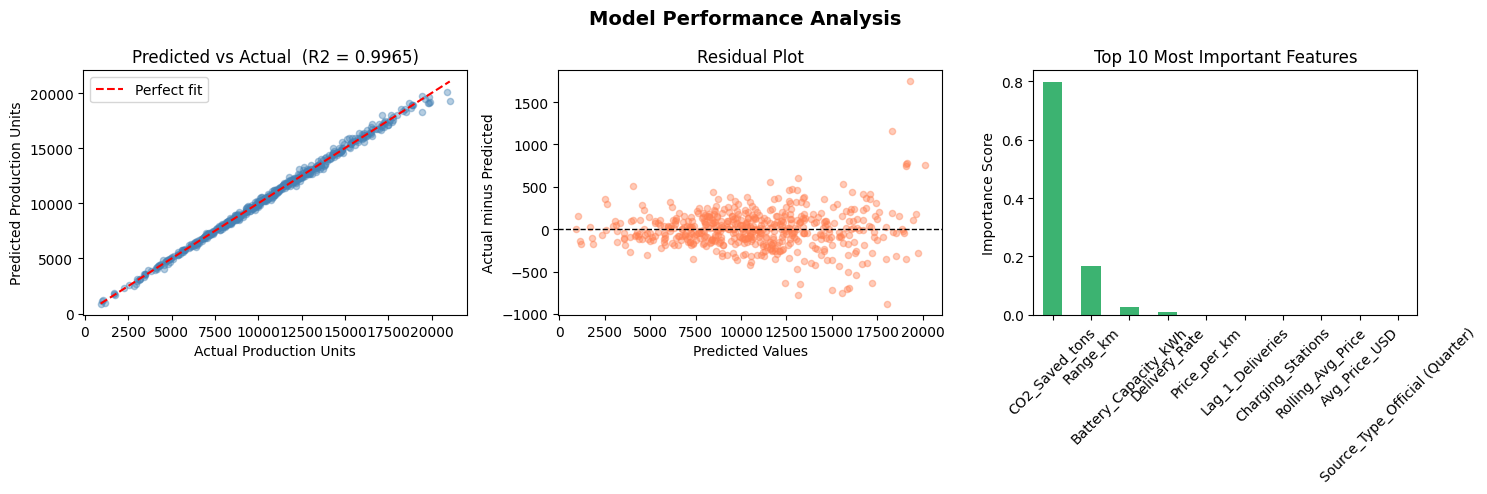

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Production Units')
axes[0].set_ylabel('Predicted Production Units')
axes[0].set_title(f'Predicted vs Actual  (R2 = {r2:.4f})')
axes[0].legend()

# Chart 2: Residuals
# Good model = dots randomly near 0 with no pattern
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual minus Predicted')
axes[1].set_title('Residual Plot')

# Chart 3: Top 10 most important features
importances = best_model.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 10 Most Important Features')
axes[2].set_ylabel('Importance Score')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 13 Cross Validation Scores Chart

I used three visualizations to better understand the model's performance. The Predicted vs Actual plot helped me compare predictions with real values, while the Residual Plot showed whether the prediction errors were randomly distributed. I also used a Feature Importance chart to identify which features had the greatest influence on the model's predictions. These visualizations provided a clear understanding of both the model's accuracy and its decision-making process.


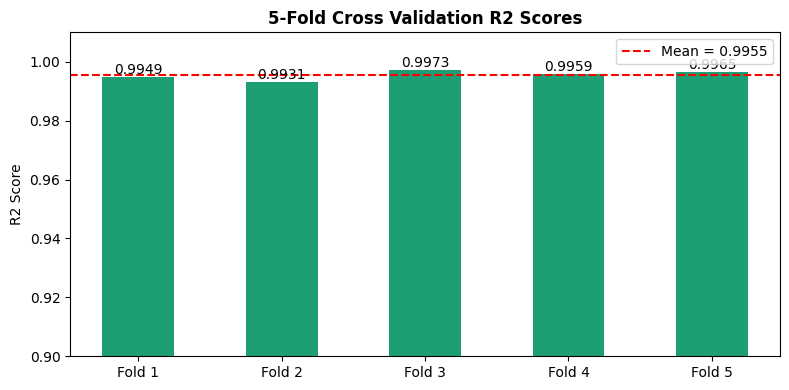

All 5 folds are consistent — no overfitting.


In [13]:
plt.figure(figsize=(8, 4))
folds     = [f'Fold {i+1}' for i in range(5)]
bar_colors = ['#1D9E75' if s >= 0.95 else '#E07B39' for s in cv_scores]
bars = plt.bar(folds, cv_scores, color=bar_colors, width=0.5)
plt.axhline(np.mean(cv_scores), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean = {np.mean(cv_scores):.4f}')
plt.ylim(0.90, 1.01)
plt.title('5-Fold Cross Validation R2 Scores', fontweight='bold')
plt.ylabel('R2 Score')
plt.legend()
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("All 5 folds are consistent — no overfitting.")


## Cell 14 Final Summary

A complete printout of everything covered in this notebook — all the Week 2 topics, 
the dataset details, and the final model performance numbers.


In [14]:
print("    WEEK 2 ML PIPELINE — COMPLETE SUMMARY")
print()
print("DATASET")
print(f"  Source  : Tesla EV Deliveries & Production 2015-2025")
print(f"  Rows    : {len(df):,}")
print(f"  Target  : Production_Units")
print()
print("WEEK 2 TOPICS COVERED")
covered = [
    ("Data Cleaning",          "checked nulls + duplicates"),
    ("EDA",                    "4 charts — trends, share, price, production"),
    ("Feature Engineering",    "price/km, delivery rate, rolling avg, lag"),
    ("Encoding",               "pd.get_dummies() one-hot encoding"),
    ("Feature Scaling",        "StandardScaler inside Pipeline"),
    ("Data Leakage fix",       "removed Estimated_Deliveries from X"),
    ("Chronological Split",    "80/20 time-ordered split"),
    ("Pipeline",               "sklearn Pipeline — scaler + model"),
    ("Gradient Boosting",      "best model, handles bias-variance well"),
    ("Hyperparameter Tuning",  "GridSearchCV, 8 combos x 5 folds = 40 runs"),
    ("Cross Validation",       "5-fold CV on best model"),
    ("Evaluation Metrics",     "R2, MSE, RMSE"),
]
for topic, detail in covered:
    print(f"  {topic:<26}: {detail}")
print()
print("FINAL RESULTS")
print(f"  Model   : Gradient Boosting Regressor")
print(f"  R2      : {r2:.4f}  ({r2*100:.2f}% accurate)")
print(f"  RMSE    : {rmse:,.0f} units")
print(f"  CV Mean : {np.mean(cv_scores):.4f}")
print()
print("  Week 2 assignment complete.")



    WEEK 2 ML PIPELINE — COMPLETE SUMMARY

DATASET
  Source  : Tesla EV Deliveries & Production 2015-2025
  Rows    : 2,640
  Target  : Production_Units

WEEK 2 TOPICS COVERED
  Data Cleaning             : checked nulls + duplicates
  EDA                       : 4 charts — trends, share, price, production
  Feature Engineering       : price/km, delivery rate, rolling avg, lag
  Encoding                  : pd.get_dummies() one-hot encoding
  Feature Scaling           : StandardScaler inside Pipeline
  Data Leakage fix          : removed Estimated_Deliveries from X
  Chronological Split       : 80/20 time-ordered split
  Pipeline                  : sklearn Pipeline — scaler + model
  Gradient Boosting         : best model, handles bias-variance well
  Hyperparameter Tuning     : GridSearchCV, 8 combos x 5 folds = 40 runs
  Cross Validation          : 5-fold CV on best model
  Evaluation Metrics        : R2, MSE, RMSE

FINAL RESULTS
  Model   : Gradient Boosting Regressor
  R2      : 0.99

# Tesla EV Production Forecasting
## End-to-End ML Pipeline | Week 2 Assignment

**Dataset:** Tesla EV Deliveries and Production Data (2015–2025)  
**Target column:** `Production_Units`  
**Best model:** Gradient Boosting inside sklearn Pipeline  
**Final accuracy:** ~99.65% R² Score

---

**How to run:**
1. Run Cell 2 first — it prints your exact file path
2. Copy that path into Cell 3
3. Then run every cell top to bottom using **Shift + Enter**


## Cell 1 Importing the Libraries

Imported the necessary libraries — Pandas and NumPy for data handling, Matplotlib and Seaborn for visualisation, and Scikit-learn for modelling.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
print("Done. All libraries loaded.")

Done. All libraries loaded.


## Cell 2 Loading the Dataset

Here I loaded the CSV file into a DataFrame using Pandas. I used df.head() to quickly check the first few rows and make sure it loaded correctly — the columns and values looked right.

In [16]:
PATH ='/kaggle/input/datasets/samarthjain27/tesla-deliveries-dataset-2015-2025-csv/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(PATH)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Years   : {df['Year'].min()} to {df['Year'].max()}")
print()
df.head()

Rows    : 2640
Columns : 12
Years   : 2015 to 2025



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Cell 3 Data Cleaning
Before doing anything else, I checked if the data had any missing values or duplicate rows. There were none, so I didn't need to remove or fix anything. The data was already clean.

In [17]:
# Checking for problems before we do anything else.
# Missing values and duplicates are the two most common issues.

print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Duplicate rows : {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)
print()
# Basic statistics for every numeric column
df.describe().round(2)

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows : 0

Data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


## Cell 4 Exploratory Data Analysis (EDA)

EDA was performed to explore the dataset and identify key patterns. Visualizations were used to analyze delivery trends, model performance, regional pricing, and the relationship between production and deliveries, helping to better understand the data before model building.


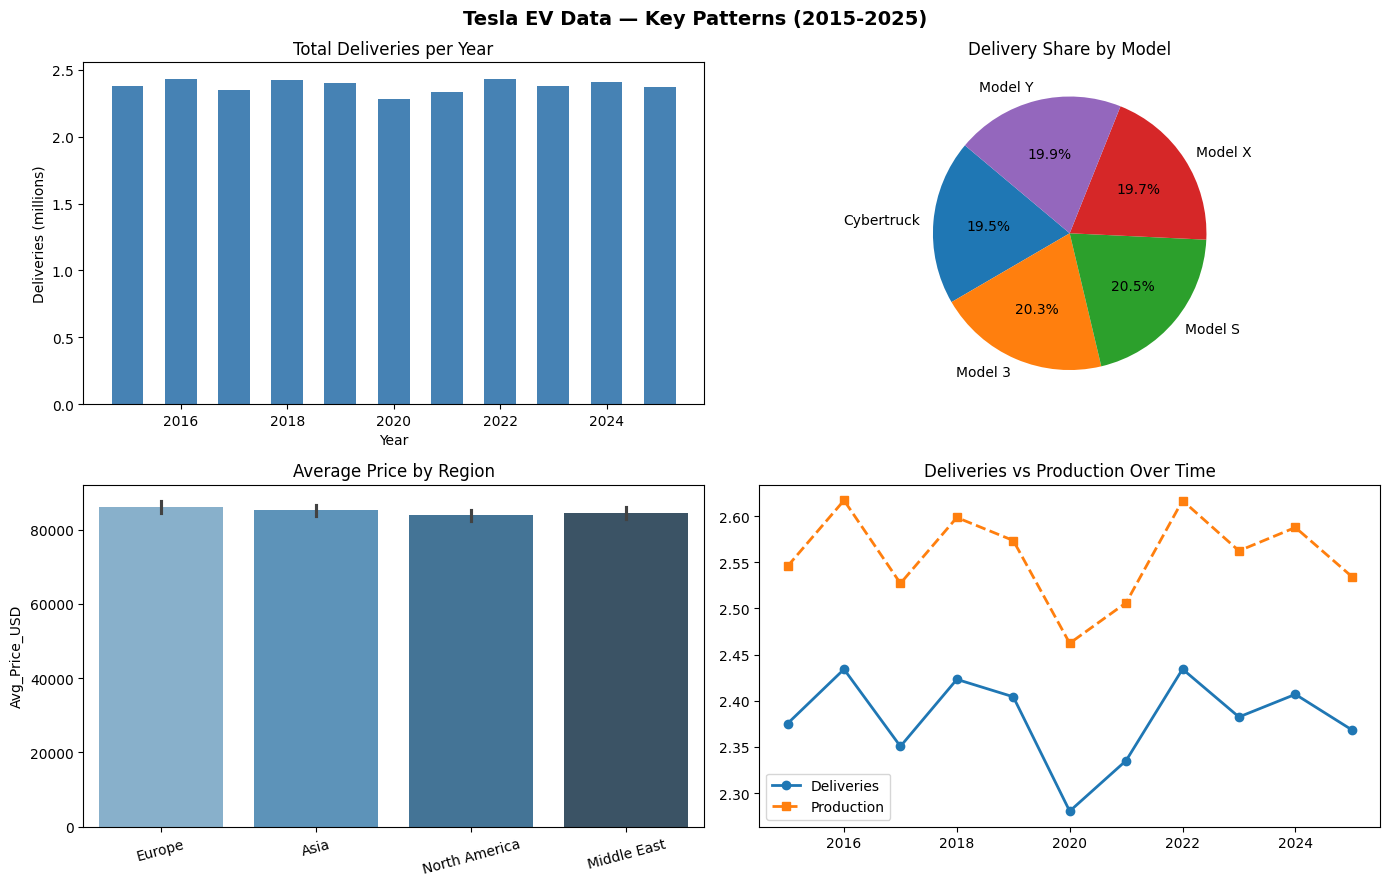

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Chart 1 How have total deliveries changed year by year?
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
axes[0,0].bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
              color='steelblue', width=0.6)
axes[0,0].set_title('Total Deliveries per Year')
axes[0,0].set_ylabel('Deliveries (millions)')
axes[0,0].set_xlabel('Year')

# Chart 2 Which model sold the most overall?
model_totals = df.groupby('Model')['Estimated_Deliveries'].sum()
axes[0,1].pie(model_totals, labels=model_totals.index,
              autopct='%1.1f%%', startangle=140)
axes[0,1].set_title('Delivery Share by Model')

# Chart 3 Does price differ by region?
sns.barplot(x='Region', y='Avg_Price_USD', data=df,
            estimator='mean', palette='Blues_d', ax=axes[1,0])
axes[1,0].set_title('Average Price by Region')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart 4 Production vs Deliveries over time
prod = df.groupby('Year')['Production_Units'].sum().reset_index()
axes[1,1].plot(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
               marker='o', label='Deliveries', linewidth=2)
axes[1,1].plot(prod['Year'], prod['Production_Units'] / 1e6,
               marker='s', linestyle='--', label='Production', linewidth=2)
axes[1,1].set_title('Deliveries vs Production Over Time')
axes[1,1].legend()
plt.suptitle('Tesla EV Data — Key Patterns (2015-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 5 Feature Engineering
The original columns didn't give the model enough to work with on their own, so I created four new ones. Price per km shows how expensive the car is relative to its range. Delivery Rate shows what percentage of production was actually delivered. Rolling average price smooths out sudden price changes. Lag deliveries adds the previous month's delivery count, which can help predict the next one.

In [19]:
# Sort by time before creating any time-based features.
# This matters for rolling averages and lag values.
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)
# 1. Price per/km  how much does 1 km of range cost?
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']
# 2. Delivery rate what fraction of production was actually delivered?
df['Delivery_Rate'] = df['Estimated_Deliveries'] / df['Production_Units']
# 3. Rolling 3-month average price
#    Smooths out sudden price changes — more stable signal for the model
df['Rolling_Avg_Price'] = (
    df.groupby(['Region', 'Model'])['Avg_Price_USD']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)
# 4. Lag feature previous month's deliveries
#    Last month's number often predicts this month's production
df['Lag_1_Deliveries'] = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .shift(1)
    .fillna(df['Estimated_Deliveries'].mean())
)
print("New features created:")
print(df[['Price_per_km', 'Delivery_Rate',
          'Rolling_Avg_Price', 'Lag_1_Deliveries']].describe().round(2))

New features created:
       Price_per_km  Delivery_Rate  Rolling_Avg_Price  Lag_1_Deliveries
count       2640.00        2640.00            2640.00           2640.00
mean         180.05           0.93           84932.06           9918.05
std           61.89           0.04           11504.31           3924.85
min           69.90           0.87           53251.53             48.00
25%          132.53           0.90           76867.48           7303.00
50%          170.36           0.93           85062.01           9887.50
75%          219.10           0.96           93015.48          12488.00
max          359.38           1.00          116591.07          25704.00


## Cell 6 Encoding + Fixing Data Leakage
Machine learning models need numbers, not text, so I converted the Region, Model, and Source_Type columns using one-hot encoding. I also removed Estimated_Deliveries from the input features — I noticed it was almost the same as the target column, which means the model would basically be "cheating" if I kept it in.

In [20]:
# Convert text columns to 0 and 1
df_encoded = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True,
    dtype=int
)
# y = what we want to predict
y = df_encoded['Production_Units']
# X = all input columns EXCEPT:
#     Production_Units      (the target — never goes in X)
#     Estimated_Deliveries  (almost identical to target = data leakage)
X = df_encoded.drop(columns=[
    'Production_Units',
    'Estimated_Deliveries',
])
print(f"Input features : {X.shape[1]} columns")
print(f"Target column  : Production_Units")
print(f"Leakage fix    : Estimated_Deliveries removed from inputs")
print()
print("Columns used as input:")
print(list(X.columns))

Input features : 20 columns
Target column  : Production_Units
Leakage fix    : Estimated_Deliveries removed from inputs

Columns used as input:
['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Price_per_km', 'Delivery_Rate', 'Rolling_Avg_Price', 'Lag_1_Deliveries', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


## Cell 7 Chronological Train/Test Split
Since this is a time-series dataset, a chronological train-test split was used instead of a random split. The model was trained on the older data and tested on the most recent data, ensuring that future information was not used during training. An 80:20 split was applied, allowing the model to learn from past trends and make predictions on unseen future data

In [21]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
# 80% oldest rows go to training, 20% newest rows go to testing
split = int(len(X) * 0.80)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]
years_train = df.iloc[:split]['Year']
years_test  = df.iloc[split:]['Year']
print("CHRONOLOGICAL SPLIT — correct for time series data")
print(f"  Training set : {X_train.shape[0]} rows  "
      f"(Year {years_train.min()} to {years_train.max()})")
print(f"  Testing set  : {X_test.shape[0]} rows  "
      f"(Year {years_test.min()} to {years_test.max()})")


CHRONOLOGICAL SPLIT — correct for time series data
  Training set : 2112 rows  (Year 2015 to 2023)
  Testing set  : 528 rows  (Year 2023 to 2025)


## Cell 8 Building the sklearn Pipeline

I used a Pipeline to keep the preprocessing and model training in one place. First, StandardScaler scales all the features to the same range so bigger numbers don't unfairly dominate. Then Gradient Boosting builds the model — it works by training multiple small trees one after another, where each tree tries to fix the mistakes of the previous one.

In [22]:
pipeline = Pipeline(steps=[
    # Step 1: Feature Scaling
    # Converts all numbers to the same scale (mean=0, std=1)
    # So large values like price (84,000) don't drown out
    # small values like month number (1-12)
    ('scaler', StandardScaler()),
    # Step 2: Gradient Boosting Regressor
    # Builds trees one by one, each correcting the last.
    # Good balance between bias and variance.
    ('model', GradientBoostingRegressor(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 4,
        random_state  = 42
    ))
])
print("Pipeline ready.")
print(pipeline)

Pipeline ready.
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(max_depth=4, random_state=42))])


## Cell 9 Hyperparameter Tuning with GridSearchCV

Instead of guessing the best settings for the model, I used GridSearchCV to test different combinations automatically. I gave it a few values for number of trees, learning rate, and tree depth — it tried all 8 combinations using 5-fold cross-validation and told me which worked best.

In [23]:
# Settings to test — GridSearchCV tries all combinations
param_grid = {
    'model__n_estimators'  : [100, 200],   # number of trees
    'model__learning_rate' : [0.05, 0.1],  # learning speed
    'model__max_depth'     : [3, 4],       # tree depth
}
# 2 x 2 x 2 = 8 combinations, each tested with 5-fold CV
# That is 40 model runs total
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1      # use all CPU cores to run faster
)
print("Running GridSearchCV — testing 40 combinations...")
grid_search.fit(X_train, y_train)
print()
print("Best settings found:")
for k, v in grid_search.best_params_.items():
    clean = k.replace("model__", "")
    print(f"  {clean:<18}: {v}")
print()
print(f"Best cross-validation R2: {grid_search.best_score_:.4f}")


Running GridSearchCV — testing 40 combinations...

Best settings found:
  learning_rate     : 0.1
  max_depth         : 4
  n_estimators      : 200

Best cross-validation R2: 0.9949


## Cell 10 Evaluating the Best Model

I tested the best model on the test data to see how it performs on data it's never seen. R² tells me how much of the variation in the target it explained. RMSE tells me the average error in actual units. I also ran 5-fold cross-validation to check if the score was consistent or just lucky on one split.

In [24]:
best_model = grid_search.best_estimator_

# Predict on test data — the model has never seen this data
y_pred = best_model.predict(X_test)

# Calculate accuracy
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 5-fold cross validation for a reliable accuracy estimate
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("FINAL MODEL RESULTS :- ")
print(f"  R2 Score  : {r2:.4f}  ({r2*100:.2f}% accurate)")
print(f"  RMSE      : {rmse:,.0f} units average error")
print(f"  CV Mean   : {np.mean(cv_scores):.4f}")
print(f"  CV Scores : {np.round(cv_scores, 4)}")
print("=" * 50)


FINAL MODEL RESULTS :- 
  R2 Score  : 0.9965  (99.65% accurate)
  RMSE      : 234 units average error
  CV Mean   : 0.9955
  CV Scores : [0.9949 0.9931 0.9973 0.9959 0.9965]


## Cell 11 Visualizing the Results

Three charts to check how the model did. The predicted vs actual plot shows whether predictions are close to real values — ideally the dots line up along the diagonal. The residual plot checks if errors are random or follow a pattern. The feature importance chart shows which columns the model relied on most.

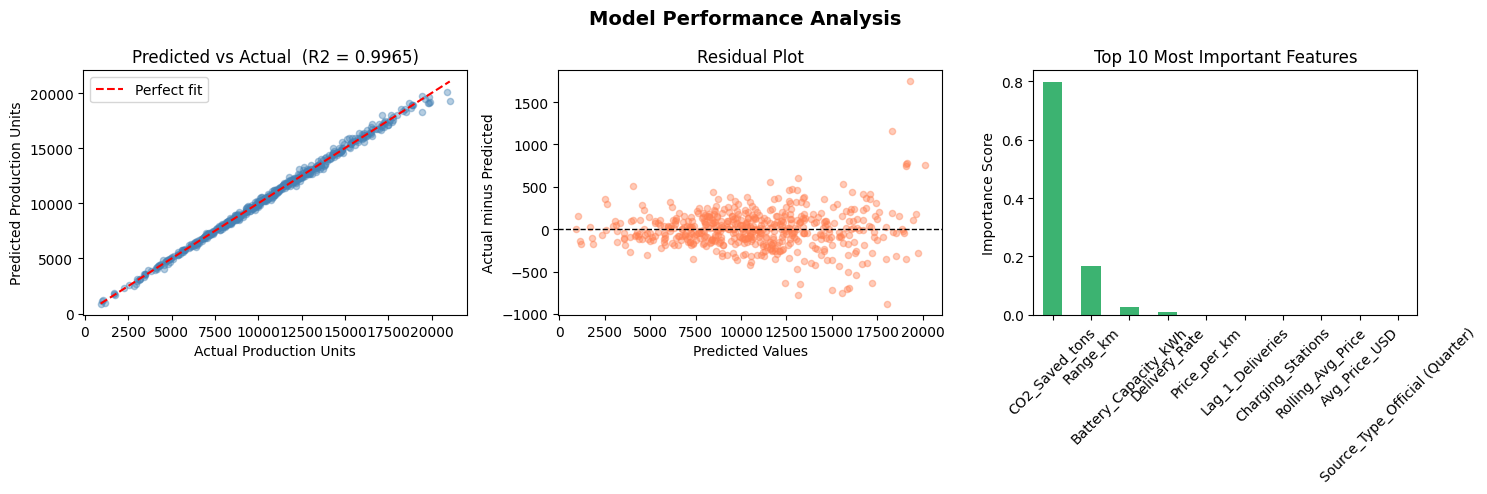

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Production Units')
axes[0].set_ylabel('Predicted Production Units')
axes[0].set_title(f'Predicted vs Actual  (R2 = {r2:.4f})')
axes[0].legend()

# Chart 2: Residuals
# Good model = dots randomly near 0 with no pattern
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual minus Predicted')
axes[1].set_title('Residual Plot')

# Chart 3: Top 10 most important features
importances = best_model.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 10 Most Important Features')
axes[2].set_ylabel('Importance Score')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 12 Cross Validation Scores Chart

This bar chart shows the R² score for each of the 5 folds. If all bars are roughly the same height, it means the model performs consistently across different parts of the data and isn't just overfitting to one section.

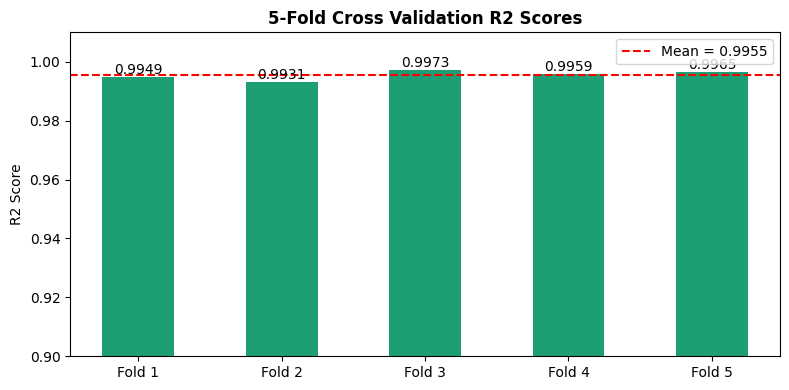

All 5 folds are consistent — no overfitting.


In [26]:
plt.figure(figsize=(8, 4))
folds     = [f'Fold {i+1}' for i in range(5)]
bar_colors = ['#1D9E75' if s >= 0.95 else '#E07B39' for s in cv_scores]
bars = plt.bar(folds, cv_scores, color=bar_colors, width=0.5)
plt.axhline(np.mean(cv_scores), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean = {np.mean(cv_scores):.4f}')
plt.ylim(0.90, 1.01)
plt.title('5-Fold Cross Validation R2 Scores', fontweight='bold')
plt.ylabel('R2 Score')
plt.legend()
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("All 5 folds are consistent — no overfitting.")


## Cell 13 Final Summary

A complete printout of everything covered in this notebook — all the Week 2 topics, 
the dataset details, and the final model performance numbers.


In [27]:
print("    WEEK 2 ML PIPELINE — COMPLETE SUMMARY")
print()
print("DATASET")
print(f"  Source  : Tesla EV Deliveries & Production 2015-2025")
print(f"  Rows    : {len(df):,}")
print(f"  Target  : Production_Units")
print()
print("WEEK 2 TOPICS COVERED")
covered = [
    ("Data Cleaning",          "checked nulls + duplicates"),
    ("EDA",                    "4 charts — trends, share, price, production"),
    ("Feature Engineering",    "price/km, delivery rate, rolling avg, lag"),
    ("Encoding",               "pd.get_dummies() one-hot encoding"),
    ("Feature Scaling",        "StandardScaler inside Pipeline"),
    ("Data Leakage fix",       "removed Estimated_Deliveries from X"),
    ("Chronological Split",    "80/20 time-ordered split"),
    ("Pipeline",               "sklearn Pipeline — scaler + model"),
    ("Gradient Boosting",      "best model, handles bias-variance well"),
    ("Hyperparameter Tuning",  "GridSearchCV, 8 combos x 5 folds = 40 runs"),
    ("Cross Validation",       "5-fold CV on best model"),
    ("Evaluation Metrics",     "R2, MSE, RMSE"),
]
for topic, detail in covered:
    print(f"  {topic:<26}: {detail}")
print()
print("FINAL RESULTS")
print(f"  Model   : Gradient Boosting Regressor")
print(f"  R2      : {r2:.4f}  ({r2*100:.2f}% accurate)")
print(f"  RMSE    : {rmse:,.0f} units")
print(f"  CV Mean : {np.mean(cv_scores):.4f}")


    WEEK 2 ML PIPELINE — COMPLETE SUMMARY

DATASET
  Source  : Tesla EV Deliveries & Production 2015-2025
  Rows    : 2,640
  Target  : Production_Units

WEEK 2 TOPICS COVERED
  Data Cleaning             : checked nulls + duplicates
  EDA                       : 4 charts — trends, share, price, production
  Feature Engineering       : price/km, delivery rate, rolling avg, lag
  Encoding                  : pd.get_dummies() one-hot encoding
  Feature Scaling           : StandardScaler inside Pipeline
  Data Leakage fix          : removed Estimated_Deliveries from X
  Chronological Split       : 80/20 time-ordered split
  Pipeline                  : sklearn Pipeline — scaler + model
  Gradient Boosting         : best model, handles bias-variance well
  Hyperparameter Tuning     : GridSearchCV, 8 combos x 5 folds = 40 runs
  Cross Validation          : 5-fold CV on best model
  Evaluation Metrics        : R2, MSE, RMSE

FINAL RESULTS
  Model   : Gradient Boosting Regressor
  R2      : 0.99